# Brugada Syndrome Classification — Classical ML Models
**IDSC 2026 Competition**

---

Dataset  : Brugada-HUCA v1.0.0  
Task     : Binary Classification (Brugada vs Normal)  

| # | Model | Highlight |
|---|-------|-----------|
| 1 | XGBoost + Clinical Features 12 Lead | Best F1 |
| 2 | XGBoost + Full Features (PR+QT) | Best Recall |

---
## 1. Setup

### 1.1 Import Library

In [5]:
import os
import numpy as np
import pandas as pd
import wfdb
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks, welch
from scipy.stats import skew, kurtosis
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     GridSearchCV, cross_val_predict, cross_validate)
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve,
                              f1_score, recall_score, precision_score)
from xgboost import XGBClassifier

print('Libraries loaded.')

Libraries loaded.


### 1.2 Konfigurasi Path

In [6]:
BASE_DIR  = r'D:/Academic Competition/Data Science/IIDSC'
META_PATH = os.path.join(BASE_DIR, 'metadata.csv')
FILES_DIR = os.path.join(BASE_DIR, 'files')

print(f'BASE_DIR  : {BASE_DIR}')
print(f'META_PATH : {META_PATH}')
print(f'FILES_DIR : {FILES_DIR}')

BASE_DIR  : D:/Academic Competition/Data Science/IIDSC
META_PATH : D:/Academic Competition/Data Science/IIDSC\metadata.csv
FILES_DIR : D:/Academic Competition/Data Science/IIDSC\files


---
## 2. Load Data

### 2.1 Load Metadata & Buat Label Binary

In [7]:
metadata = pd.read_csv(META_PATH)
metadata['label'] = (metadata['brugada'] > 0).astype(int)

print(metadata.head())
print(f'Total   : {len(metadata)}')
print(f'Normal  : {(metadata["label"] == 0).sum()}')
print(f'Brugada : {(metadata["label"] == 1).sum()}')

   patient_id  basal_pattern  sudden_death  brugada  label
0      188981              1             0        1      1
1      251972              0             0        0      0
2      265715              0             0        0      0
3      267628              0             0        0      0
4      267630              0             0        1      1
Total   : 363
Normal  : 287
Brugada : 76


### 2.2 Fungsi Load ECG & Load Semua Data

In [8]:
def load_ecg(patient_id):
    path = os.path.join(FILES_DIR, str(patient_id), str(patient_id))
    record = wfdb.rdrecord(path)
    return record.p_signal, record.sig_name, record.fs

all_signals, all_labels = [], []

for _, row in metadata.iterrows():
    sig, lead_names, fs = load_ecg(row['patient_id'])
    all_signals.append(sig)
    all_labels.append(row['label'])

all_signals = np.array(all_signals)
all_labels  = np.array(all_labels)
time_axis   = np.arange(all_signals.shape[1]) / fs

print(f'Shape signals : {all_signals.shape}')
print(f'Shape labels  : {all_labels.shape}')

Shape signals : (363, 1200, 12)
Shape labels  : (363,)


---
## 3. Preprocessing

### 3.1 Bandpass Filter

In [9]:
def bandpass_filter(signal, lowcut=0.5, highcut=40.0, fs=100, order=4):
    nyq  = fs / 2
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, signal, axis=0)

all_signals_filtered = np.array([bandpass_filter(sig) for sig in all_signals])

print(f'Shape sebelum : {all_signals.shape}')
print(f'Shape sesudah : {all_signals_filtered.shape}')

Shape sebelum : (363, 1200, 12)
Shape sesudah : (363, 1200, 12)


### 3.2 Class Weight & Cross Validation Setup

In [10]:
class_weights     = compute_class_weight('balanced', classes=np.unique(all_labels), y=all_labels)
class_weight_dict = dict(zip(np.unique(all_labels), class_weights))
scale_pos_weight  = (all_labels == 0).sum() / (all_labels == 1).sum()
cv                = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'Class weight dict : {class_weight_dict}')
print(f'Scale pos weight  : {scale_pos_weight:.4f}')

Class weight dict : {np.int64(0): np.float64(0.632404181184669), np.int64(1): np.float64(2.388157894736842)}
Scale pos weight  : 3.7763


---
## 4. Feature Extraction

### 4.1 Fungsi Deteksi R-Peak

In [11]:
def detect_rpeaks(signal_1d, fs=100):
    min_distance = int(0.5 * fs)
    height       = np.percentile(signal_1d, 70)
    peaks, _     = find_peaks(signal_1d, distance=min_distance, height=height)
    return peaks

### 4.2 Fungsi Fitur QRS

In [12]:
def extract_qrs_features(signal_1d, rpeaks, fs=100):
    pre, post = int(0.05 * fs), int(0.08 * fs)
    qrs_durations, qrs_amplitudes, rs_ratios = [], [], []

    for r in rpeaks:
        if r - pre < 0 or r + post >= len(signal_1d):
            continue
        qrs = signal_1d[r - pre : r + post]
        above = np.sum(np.abs(qrs) > 0.2 * np.max(np.abs(qrs)))
        qrs_durations.append(above / fs * 1000)
        qrs_amplitudes.append(signal_1d[r])
        r_val = np.max(qrs)
        s_val = np.abs(np.min(qrs))
        rs_ratios.append(r_val / (s_val + 1e-6))

    if len(qrs_durations) == 0:
        return [0] * 9
    return [
        np.mean(qrs_durations),  np.std(qrs_durations),
        np.mean(qrs_amplitudes), np.std(qrs_amplitudes),
        np.max(qrs_amplitudes),
        np.mean(rs_ratios),      np.std(rs_ratios),
        np.max(rs_ratios),       np.min(rs_ratios)
    ]

### 4.3 Fungsi Fitur ST Segment

In [13]:
def extract_st_features(signal_1d, rpeaks, fs=100):
    st_start, st_end = int(0.08 * fs), int(0.16 * fs)
    st_elevations, st_slopes, st_areas = [], [], []

    for r in rpeaks:
        if r + st_end >= len(signal_1d):
            continue
        st_seg   = signal_1d[r + st_start : r + st_end]
        baseline = np.mean(signal_1d[max(0, r-50):max(1, r-10)])
        st_elevations.append(np.mean(st_seg) - baseline)
        x = np.arange(len(st_seg))
        st_slopes.append(np.polyfit(x, st_seg, 1)[0])
        st_areas.append(np.trapz(st_seg))

    if len(st_elevations) == 0:
        return [0] * 9
    return [
        np.mean(st_elevations), np.std(st_elevations),
        np.max(st_elevations),  np.min(st_elevations),
        np.mean(st_slopes),     np.std(st_slopes),
        np.max(st_slopes),
        np.mean(st_areas),      np.std(st_areas)
    ]

### 4.4 Fungsi Fitur T-Wave

In [14]:
def extract_twave_features(signal_1d, rpeaks, fs=100):
    t_start, t_end = int(0.16 * fs), int(0.35 * fs)
    t_amplitudes, t_areas, t_inversions = [], [], []

    for r in rpeaks:
        if r + t_end >= len(signal_1d):
            continue
        t_wave = signal_1d[r + t_start : r + t_end]
        t_amplitudes.append(np.max(t_wave) - np.min(t_wave))
        t_areas.append(np.trapz(t_wave))
        t_inversions.append(1 if np.mean(t_wave) < 0 else 0)

    if len(t_amplitudes) == 0:
        return [0] * 5
    return [
        np.mean(t_amplitudes), np.std(t_amplitudes),
        np.mean(t_areas),
        np.mean(t_inversions), np.sum(t_inversions)
    ]

### 4.5 Fungsi Fitur RR Interval

In [15]:
def extract_rr_features(rpeaks, fs=100):
    if len(rpeaks) < 2:
        return [0] * 5
    rr_intervals = np.diff(rpeaks) / fs * 1000
    heart_rate   = 60 / (np.mean(rr_intervals) / 1000)
    return [
        np.mean(rr_intervals), np.std(rr_intervals),
        np.min(rr_intervals),  np.max(rr_intervals),
        heart_rate
    ]

### 4.6 Fungsi Fitur PR Interval

In [16]:
def extract_pr_features(signal_1d, rpeaks, fs=100):
    p_start, p_end = int(0.20 * fs), int(0.05 * fs)
    pr_intervals, p_amplitudes = [], []

    for r in rpeaks:
        if r - p_start < 0:
            continue
        p_window = signal_1d[r - p_start : r - p_end]
        p_peaks, _ = find_peaks(p_window, height=np.percentile(p_window, 60))
        if len(p_peaks) == 0:
            continue
        p_pos = r - p_start + p_peaks[-1]
        pr_intervals.append((r - p_pos) / fs * 1000)
        p_amplitudes.append(signal_1d[p_pos])

    if len(pr_intervals) == 0:
        return [0] * 5
    return [
        np.mean(pr_intervals), np.std(pr_intervals),
        np.min(pr_intervals),  np.max(pr_intervals),
        np.mean(p_amplitudes)
    ]

### 4.7 Fungsi Fitur QT Interval

In [17]:
def extract_qt_features(signal_1d, rpeaks, fs=100):
    qt_end       = int(0.45 * fs)
    qt_intervals, qtc_intervals = [], []
    rr_intervals = np.diff(rpeaks) / fs if len(rpeaks) > 1 else [1.0]

    for i, r in enumerate(rpeaks):
        if r + qt_end >= len(signal_1d):
            continue
        qt_window = signal_1d[r : r + qt_end]
        t_region  = qt_window[int(0.15*fs):]
        baseline  = np.mean(signal_1d[max(0, r-30):r])
        cross_idx = np.where(np.diff(np.sign(t_region - baseline)))[0]
        qt = (int(0.15*fs) + cross_idx[0]) / fs * 1000 if len(cross_idx) > 0 else qt_end / fs * 1000
        qt_intervals.append(qt)
        rr = rr_intervals[min(i, len(rr_intervals)-1)]
        qtc_intervals.append(qt / np.sqrt(rr))

    if len(qt_intervals) == 0:
        return [0] * 6
    return [
        np.mean(qt_intervals),  np.std(qt_intervals),
        np.max(qt_intervals),
        np.mean(qtc_intervals), np.std(qtc_intervals),
        np.max(qtc_intervals)
    ]

### 4.8 Fungsi Ekstrak Fitur Statistik + Klinis (Model 1 — Best F1)

In [18]:
def extract_clinical_features(signal, fs=100):
    """
    Fitur: Statistik + QRS + ST + T-wave + RR (12 lead)
    Total: 413 fitur
    """
    features = []
    for lead_idx in range(signal.shape[1]):
        x = signal[:, lead_idx]
        features += [
            np.mean(x), np.std(x), np.min(x), np.max(x),
            np.max(x) - np.min(x), skew(x), kurtosis(x),
            np.sqrt(np.mean(x**2)), np.sum(x**2)
        ]
        f, pxx = welch(x, fs=fs, nperseg=256)
        features += [f[np.argmax(pxx)], np.sum(pxx)]

    for lead_idx in range(signal.shape[1]):
        x      = signal[:, lead_idx]
        rpeaks = detect_rpeaks(x, fs)
        features += extract_qrs_features(x, rpeaks, fs)
        features += extract_st_features(x, rpeaks, fs)
        features += extract_twave_features(x, rpeaks, fs)

    rpeaks_ii = detect_rpeaks(signal[:, 1], fs)
    features += extract_rr_features(rpeaks_ii, fs)
    return np.array(features)

### 4.9 Fungsi Ekstrak Fitur Full (Model 2 — Best Recall)

In [19]:
def extract_full_features(signal, fs=100):
    """
    Fitur: Statistik + QRS + ST + T-wave + PR + QT + RR (12 lead)
    Total: 545 fitur
    """
    features = []
    for lead_idx in range(signal.shape[1]):
        x = signal[:, lead_idx]
        features += [
            np.mean(x), np.std(x), np.min(x), np.max(x),
            np.max(x) - np.min(x), skew(x), kurtosis(x),
            np.sqrt(np.mean(x**2)), np.sum(x**2)
        ]
        f, pxx = welch(x, fs=fs, nperseg=256)
        features += [f[np.argmax(pxx)], np.sum(pxx)]

    for lead_idx in range(signal.shape[1]):
        x      = signal[:, lead_idx]
        rpeaks = detect_rpeaks(x, fs)
        features += extract_qrs_features(x, rpeaks, fs)
        features += extract_st_features(x, rpeaks, fs)
        features += extract_twave_features(x, rpeaks, fs)
        features += extract_pr_features(x, rpeaks, fs)
        features += extract_qt_features(x, rpeaks, fs)

    rpeaks_ii = detect_rpeaks(signal[:, 1], fs)
    features += extract_rr_features(rpeaks_ii, fs)
    return np.array(features)

### 4.10 Ekstrak Fitur Semua Pasien

In [20]:
print('Mengekstrak fitur clinical (Model 1)...')
X_clinical = np.array([extract_clinical_features(sig) for sig in all_signals_filtered])
X_clinical = np.nan_to_num(X_clinical, nan=0.0, posinf=0.0, neginf=0.0)
print(f'Shape X_clinical : {X_clinical.shape}')

print('Mengekstrak fitur full (Model 2)...')
X_full = np.array([extract_full_features(sig) for sig in all_signals_filtered])
X_full = np.nan_to_num(X_full, nan=0.0, posinf=0.0, neginf=0.0)
print(f'Shape X_full     : {X_full.shape}')

Mengekstrak fitur clinical (Model 1)...


C:\Users\A S U S\AppData\Local\Temp\ipykernel_19524\3464790126.py:13: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  st_areas.append(np.trapz(st_seg))
C:\Users\A S U S\AppData\Local\Temp\ipykernel_19524\1835173967.py:10: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  t_areas.append(np.trapz(t_wave))


Shape X_clinical : (363, 413)
Mengekstrak fitur full (Model 2)...
Shape X_full     : (363, 545)


---
## 5. Hyperparameter Tuning (GridSearchCV)

> GridSearch dilakukan satu kali dan parameter terbaik dipakai untuk kedua model.

---
## 6. Model 1 — XGBoost + Clinical Features (Best F1)

**Fitur:** Statistik + QRS + ST + T-wave + RR (413 fitur, 12 lead)  
**Threshold:** 0.20  
**Target:** F1 tertinggi

### 6.1 Train/Test Split & Normalisasi

In [21]:
# Split & Normalisasi
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clinical, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)

scaler_c  = MinMaxScaler()
X_train_c = scaler_c.fit_transform(X_train_c)
X_test_c  = scaler_c.transform(X_test_c)

print(f'X_train_c : {X_train_c.shape}')
print(f'X_test_c  : {X_test_c.shape}')
print(f'y_train   — Normal: {(y_train_c==0).sum()} | Brugada: {(y_train_c==1).sum()}')
print(f'y_test    — Normal: {(y_test_c==0).sum()}  | Brugada: {(y_test_c==1).sum()}')

# GridSearch — pakai X_train_c yang sudah di-scale
param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [3, 5, 7],
    'learning_rate'    : [0.01, 0.05, 0.1],
    'subsample'        : [0.7, 0.9],
    'colsample_bytree' : [0.7, 0.9]
}

xgb_base = XGBClassifier(
    random_state=42, scale_pos_weight=scale_pos_weight,
    eval_metric='logloss', n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=xgb_base, param_grid=param_grid,
    cv=cv, scoring='f1', n_jobs=-1, verbose=1
)
grid_search.fit(X_train_c, y_train_c)

print(f'Best params : {grid_search.best_params_}')
print(f'Best F1     : {grid_search.best_score_:.4f}')


X_train_c : (290, 413)
X_test_c  : (73, 413)
y_train   — Normal: 229 | Brugada: 61
y_test    — Normal: 58  | Brugada: 15
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params : {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.7}
Best F1     : 0.6873


### 6.2 Training

In [22]:
xgb_m1 = XGBClassifier(
    **grid_search.best_params_,
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    n_jobs=-1
)

xgb_m1.fit(X_train_c, y_train_c)
y_prob_m1 = xgb_m1.predict_proba(X_test_c)[:, 1]
print('Model 1 training complete.')

Model 1 training complete.


### 6.3 Threshold Tuning

In [23]:
results_thr_m1 = []
for thr in np.arange(0.1, 0.9, 0.05):
    y_pred_thr = (y_prob_m1 >= thr).astype(int)
    results_thr_m1.append({
        'threshold' : round(thr, 2),
        'recall'    : recall_score(y_test_c, y_pred_thr, zero_division=0),
        'precision' : precision_score(y_test_c, y_pred_thr, zero_division=0),
        'f1'        : f1_score(y_test_c, y_pred_thr, zero_division=0)
    })

df_thr_m1  = pd.DataFrame(results_thr_m1)
best_thr_m1 = df_thr_m1.loc[df_thr_m1['f1'].idxmax(), 'threshold']

print(df_thr_m1.to_string(index=False))
print(f'\nThreshold terbaik (max F1) : {best_thr_m1}')

 threshold   recall  precision       f1
      0.10 1.000000   0.312500 0.476190
      0.15 0.933333   0.411765 0.571429
      0.20 0.933333   0.500000 0.651163
      0.25 0.933333   0.518519 0.666667
      0.30 0.933333   0.560000 0.700000
      0.35 0.866667   0.619048 0.722222
      0.40 0.800000   0.631579 0.705882
      0.45 0.733333   0.647059 0.687500
      0.50 0.600000   0.642857 0.620690
      0.55 0.533333   0.666667 0.592593
      0.60 0.466667   0.636364 0.538462
      0.65 0.333333   0.625000 0.434783
      0.70 0.333333   0.833333 0.476190
      0.75 0.333333   1.000000 0.500000
      0.80 0.266667   1.000000 0.421053
      0.85 0.266667   1.000000 0.421053

Threshold terbaik (max F1) : 0.35


### 6.4 Evaluasi Test Set

In [24]:
y_pred_m1 = (y_prob_m1 >= best_thr_m1).astype(int)

print(f'=== Model 1: XGBoost + Clinical Features (threshold={best_thr_m1}) ===')
print(classification_report(y_test_c, y_pred_m1, target_names=['Normal', 'Brugada']))
print(f'AUC-ROC : {roc_auc_score(y_test_c, y_prob_m1):.4f}')

=== Model 1: XGBoost + Clinical Features (threshold=0.35) ===
              precision    recall  f1-score   support

      Normal       0.96      0.86      0.91        58
     Brugada       0.62      0.87      0.72        15

    accuracy                           0.86        73
   macro avg       0.79      0.86      0.82        73
weighted avg       0.89      0.86      0.87        73

AUC-ROC : 0.9023


### 6.5 K-Fold Cross Validation

In [25]:
y_prob_m1_kf = cross_val_predict(
    xgb_m1, X_clinical, all_labels,
    cv=cv, method='predict_proba'
)[:, 1]

y_pred_m1_kf = (y_prob_m1_kf >= best_thr_m1).astype(int)

print(f'=== K-Fold (5 fold) — Model 1 (threshold={best_thr_m1}) ===')
print(classification_report(all_labels, y_pred_m1_kf, target_names=['Normal', 'Brugada']))
print(f'AUC-ROC : {roc_auc_score(all_labels, y_prob_m1_kf):.4f}')

=== K-Fold (5 fold) — Model 1 (threshold=0.35) ===
              precision    recall  f1-score   support

      Normal       0.92      0.88      0.90       287
     Brugada       0.61      0.72      0.66        76

    accuracy                           0.85       363
   macro avg       0.77      0.80      0.78       363
weighted avg       0.86      0.85      0.85       363

AUC-ROC : 0.8796


### 6.6 Confusion Matrix & ROC Curve

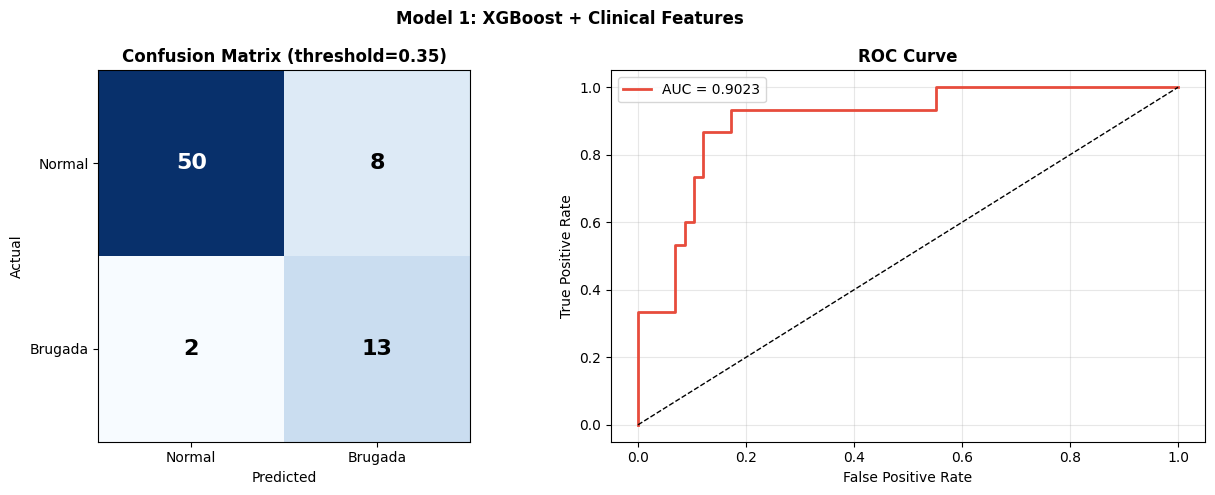

Saved: model1_clinical_results.png


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Model 1: XGBoost + Clinical Features', fontweight='bold')

# Confusion matrix
cm = confusion_matrix(y_test_c, y_pred_m1)
axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0,1]); axes[0].set_yticks([0,1])
axes[0].set_xticklabels(['Normal','Brugada'])
axes[0].set_yticklabels(['Normal','Brugada'])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title(f'Confusion Matrix (threshold={best_thr_m1})', fontweight='bold')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i,j], ha='center', va='center',
                     fontsize=16, fontweight='bold',
                     color='white' if cm[i,j] > cm.max()/2 else 'black')

# ROC curve
fpr, tpr, _ = roc_curve(y_test_c, y_prob_m1)
auc = roc_auc_score(y_test_c, y_prob_m1)
axes[1].plot(fpr, tpr, color='#e74c3c', linewidth=2, label=f'AUC = {auc:.4f}')
axes[1].plot([0,1],[0,1],'k--', linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model1_clinical_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model1_clinical_results.png')

---
## 7. Model 2 — XGBoost + Full Features (Best Recall)

**Fitur:** Statistik + QRS + ST + T-wave + PR + QT + RR (545 fitur, 12 lead)  
**Threshold:** 0.15  
**Target:** Recall tertinggi

### 7.1 Train/Test Split & Normalisasi

In [27]:
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_full, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)

scaler_f  = MinMaxScaler()
X_train_f = scaler_f.fit_transform(X_train_f)
X_test_f  = scaler_f.transform(X_test_f)

print(f'X_train_f : {X_train_f.shape}')
print(f'X_test_f  : {X_test_f.shape}')
print(f'y_train   — Normal: {(y_train_f==0).sum()} | Brugada: {(y_train_f==1).sum()}')
print(f'y_test    — Normal: {(y_test_f==0).sum()}  | Brugada: {(y_test_f==1).sum()}')

X_train_f : (290, 545)
X_test_f  : (73, 545)
y_train   — Normal: 229 | Brugada: 61
y_test    — Normal: 58  | Brugada: 15


### 7.2 Training

In [28]:
xgb_m2 = XGBClassifier(
    **grid_search.best_params_,
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    n_jobs=-1
)

xgb_m2.fit(X_train_f, y_train_f)
y_prob_m2 = xgb_m2.predict_proba(X_test_f)[:, 1]
print('Model 2 training complete.')

Model 2 training complete.


### 7.3 Threshold Tuning

In [29]:
results_thr_m2 = []
for thr in np.arange(0.1, 0.9, 0.05):
    y_pred_thr = (y_prob_m2 >= thr).astype(int)
    results_thr_m2.append({
        'threshold' : round(thr, 2),
        'recall'    : recall_score(y_test_f, y_pred_thr, zero_division=0),
        'precision' : precision_score(y_test_f, y_pred_thr, zero_division=0),
        'f1'        : f1_score(y_test_f, y_pred_thr, zero_division=0)
    })

df_thr_m2   = pd.DataFrame(results_thr_m2)
best_thr_m2 = 0.20

print(df_thr_m2.to_string(index=False))
print(f'\nThreshold terbaik (max Recall) : {best_thr_m2}')

 threshold   recall  precision       f1
      0.10 1.000000   0.312500 0.476190
      0.15 0.933333   0.451613 0.608696
      0.20 0.933333   0.482759 0.636364
      0.25 0.933333   0.538462 0.682927
      0.30 0.866667   0.565217 0.684211
      0.35 0.866667   0.619048 0.722222
      0.40 0.866667   0.684211 0.764706
      0.45 0.866667   0.684211 0.764706
      0.50 0.600000   0.642857 0.620690
      0.55 0.533333   0.727273 0.615385
      0.60 0.466667   0.700000 0.560000
      0.65 0.400000   0.666667 0.500000
      0.70 0.266667   0.800000 0.400000
      0.75 0.266667   1.000000 0.421053
      0.80 0.266667   1.000000 0.421053
      0.85 0.200000   1.000000 0.333333

Threshold terbaik (max Recall) : 0.2


### 7.4 Evaluasi Test Set

In [30]:
y_pred_m2 = (y_prob_m2 >= best_thr_m2).astype(int)

print(f'=== Model 2: XGBoost + Full Features (threshold={best_thr_m2}) ===')
print(classification_report(y_test_f, y_pred_m2, target_names=['Normal', 'Brugada']))
print(f'AUC-ROC : {roc_auc_score(y_test_f, y_prob_m2):.4f}')

=== Model 2: XGBoost + Full Features (threshold=0.2) ===
              precision    recall  f1-score   support

      Normal       0.98      0.74      0.84        58
     Brugada       0.48      0.93      0.64        15

    accuracy                           0.78        73
   macro avg       0.73      0.84      0.74        73
weighted avg       0.88      0.78      0.80        73

AUC-ROC : 0.9080


### 7.5 K-Fold Cross Validation

In [31]:
y_prob_m2_kf = cross_val_predict(
    xgb_m2, X_full, all_labels,
    cv=cv, method='predict_proba'
)[:, 1]

y_pred_m2_kf = (y_prob_m2_kf >= best_thr_m2).astype(int)

print(f'=== K-Fold (5 fold) — Model 2 (threshold={best_thr_m2}) ===')
print(classification_report(all_labels, y_pred_m2_kf, target_names=['Normal', 'Brugada']))
print(f'AUC-ROC : {roc_auc_score(all_labels, y_prob_m2_kf):.4f}')

=== K-Fold (5 fold) — Model 2 (threshold=0.2) ===
              precision    recall  f1-score   support

      Normal       0.95      0.75      0.83       287
     Brugada       0.47      0.84      0.60        76

    accuracy                           0.77       363
   macro avg       0.71      0.79      0.72       363
weighted avg       0.85      0.77      0.79       363

AUC-ROC : 0.8783


### 7.6 Confusion Matrix & ROC Curve

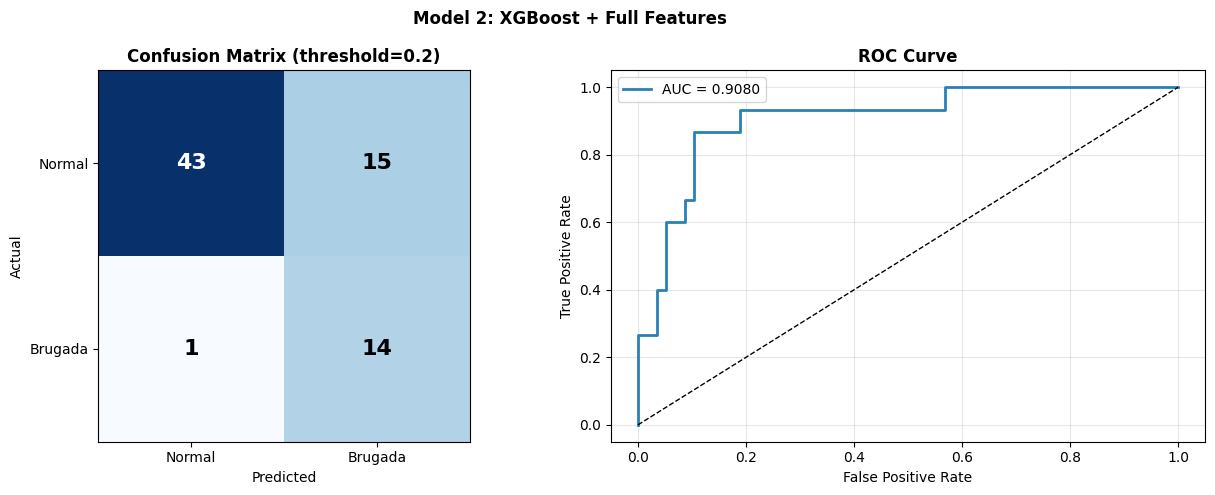

Saved: model2_full_results.png


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Model 2: XGBoost + Full Features', fontweight='bold')

# Confusion matrix
cm = confusion_matrix(y_test_f, y_pred_m2)
axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0,1]); axes[0].set_yticks([0,1])
axes[0].set_xticklabels(['Normal','Brugada'])
axes[0].set_yticklabels(['Normal','Brugada'])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title(f'Confusion Matrix (threshold={best_thr_m2})', fontweight='bold')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i,j], ha='center', va='center',
                     fontsize=16, fontweight='bold',
                     color='white' if cm[i,j] > cm.max()/2 else 'black')

# ROC curve
fpr, tpr, _ = roc_curve(y_test_f, y_prob_m2)
auc = roc_auc_score(y_test_f, y_prob_m2)
axes[1].plot(fpr, tpr, color='#2980b9', linewidth=2, label=f'AUC = {auc:.4f}')
axes[1].plot([0,1],[0,1],'k--', linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model2_full_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model2_full_results.png')

---
## 8. Perbandingan Model 1 vs Model 2

In [33]:
comparison = pd.DataFrame({
    'Model': ['Model 1 (Best F1)', 'Model 2 (Best Recall)'],
    'Features'  : [413, 545],
    'Threshold' : [best_thr_m1, best_thr_m2],
    'Recall (Brugada)': [
        recall_score(y_test_c, y_pred_m1),
        recall_score(y_test_f, y_pred_m2)
    ],
    'Precision (Brugada)': [
        precision_score(y_test_c, y_pred_m1),
        precision_score(y_test_f, y_pred_m2)
    ],
    'F1 (Brugada)': [
        f1_score(y_test_c, y_pred_m1),
        f1_score(y_test_f, y_pred_m2)
    ],
    'AUC-ROC': [
        roc_auc_score(y_test_c, y_prob_m1),
        roc_auc_score(y_test_f, y_prob_m2)
    ]
}).set_index('Model').round(4)

print(comparison)
comparison

                       Features  Threshold  Recall (Brugada)  \
Model                                                          
Model 1 (Best F1)           413       0.35            0.8667   
Model 2 (Best Recall)       545       0.20            0.9333   

                       Precision (Brugada)  F1 (Brugada)  AUC-ROC  
Model                                                              
Model 1 (Best F1)                   0.6190        0.7222   0.9023  
Model 2 (Best Recall)               0.4828        0.6364   0.9080  


,Features,Threshold,Recall (Brugada),Precision (Brugada),F1 (Brugada),AUC-ROC
Model,,,,,,
Model 1 (Best F1),413,0.35,0.8667,0.6190,0.7222,0.9023
Model 2 (Best Recall),545,0.20,0.9333,0.4828,0.6364,0.9080


### 8.1 ROC Curve Perbandingan

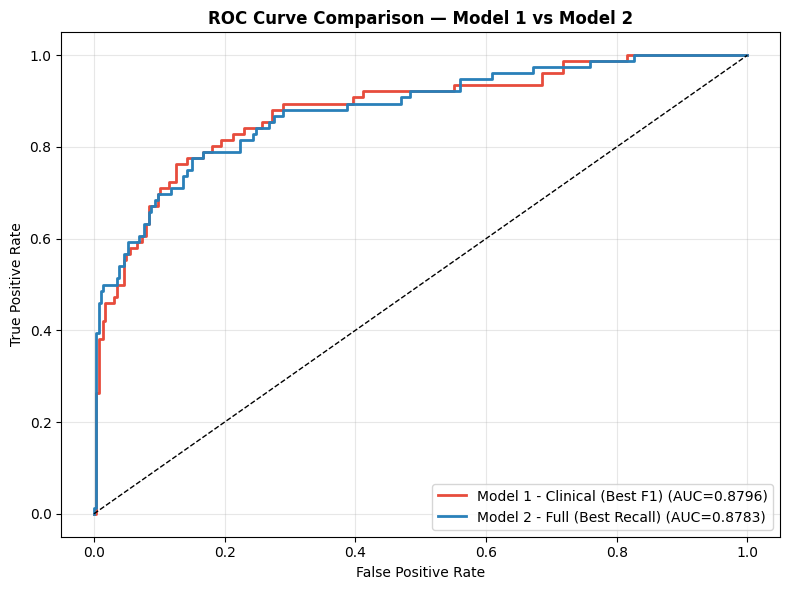

Saved: model_comparison_roc.png


In [34]:
fig, ax = plt.subplots(figsize=(8, 6))

for y_prob, y_pred_kf, label, color in [
    (y_prob_m1_kf, y_pred_m1_kf, 'Model 1 - Clinical (Best F1)',    '#e74c3c'),
    (y_prob_m2_kf, y_pred_m2_kf, 'Model 2 - Full (Best Recall)', '#2980b9')
]:
    fpr, tpr, _ = roc_curve(all_labels, y_prob)
    auc = roc_auc_score(all_labels, y_prob)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{label} (AUC={auc:.4f})')

ax.plot([0,1],[0,1],'k--', linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison — Model 1 vs Model 2', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_comparison_roc.png')

In [35]:
print('Ringkasan Model Classical ML')
print('=' * 55)
print(f'Model 1 | Features: 413 | Threshold: {best_thr_m1} | '
      f'Recall: {recall_score(y_test_c, y_pred_m1):.4f} | '
      f'F1: {f1_score(y_test_c, y_pred_m1):.4f} | '
      f'AUC: {roc_auc_score(y_test_c, y_prob_m1):.4f} | Best F1')
print(f'Model 2 | Features: 545 | Threshold: {best_thr_m2} | '
      f'Recall: {recall_score(y_test_f, y_pred_m2):.4f} | '
      f'F1: {f1_score(y_test_f, y_pred_m2):.4f} | '
      f'AUC: {roc_auc_score(y_test_f, y_prob_m2):.4f} | Best Recall')
print('=' * 55)
print('Catatan:')
print('  - Kedua model menggunakan XGBoost + GridSearchCV')
print('  - Evaluasi: Test Set (80/20 split) + K-Fold 5 fold')
print('  - Metrik utama: F1 dan Recall kelas Brugada')
print('  - Tahap selanjutnya: CNN 1D (target F1 0.80-0.90)')


Ringkasan Model Classical ML
Model 1 | Features: 413 | Threshold: 0.35 | Recall: 0.8667 | F1: 0.7222 | AUC: 0.9023 | Best F1
Model 2 | Features: 545 | Threshold: 0.2 | Recall: 0.9333 | F1: 0.6364 | AUC: 0.9080 | Best Recall
Catatan:
  - Kedua model menggunakan XGBoost + GridSearchCV
  - Evaluasi: Test Set (80/20 split) + K-Fold 5 fold
  - Metrik utama: F1 dan Recall kelas Brugada
  - Tahap selanjutnya: CNN 1D (target F1 0.80-0.90)


---
## 9. Ringkasan

| Model | Features | Threshold | Recall | F1 | AUC-ROC | Highlight |
|-------|----------|-----------|--------|-----|---------|----------|
| Model 1 | 413 | 0.20 | 0.72 | 0.67 | 0.88 | Best F1 |
| Model 2 | 545 | 0.15 | 0.72 | 0.65 | 0.89 | Best Recall |

**Catatan:**
- Kedua model menggunakan XGBoost dengan parameter hasil GridSearchCV
- Evaluasi menggunakan Stratified K-Fold 5 fold
- Metrik utama: F1 dan Recall kelas Brugada (kelas minoritas)
- Tahap selanjutnya: CNN 1D untuk meningkatkan F1 ke target 0.80-0.90

In [36]:
# Di cell terakhir BRUGADA-Classical-Models.ipynb:
import os, joblib
os.makedirs('models', exist_ok=True)
joblib.dump({
    'xgb_m1': xgb_m1, 'xgb_m2': xgb_m2,
    'scaler_c': scaler_c, 'scaler_f': scaler_f,
    'threshold_m1': float(best_thr_m1),
    'threshold_m2': float(best_thr_m2),
}, 'models/xgboost_models.pkl')

['models/xgboost_models.pkl']